In [13]:
## Here, we implement a Hopfield model for dynamical learning.
## Classification is performed by dynamically evolving the data, provided as initial conditions,
## toward the corresponding labels, implemented as crafted attractors in phase space.
## The learning process therefore consists of sculpting the basins of attraction of these attractors.

## This version uses JAX. The time-dependent Euler integration loop in the core model
## is implemented with `jax.lax.scan` and JIT compilation.

## If you use this code, please cite the following papers:

## Lorenzo Chicchi et al 2025 Mach. Learn.: Sci. Technol. 6 035054
## Stefano Gagliani et al 2026 Mach. Learn.: Sci. Technol. 7 025020


In [14]:
import functools
import math
import time

import jax
import jax.numpy as jnp
from jax import lax, random
import optax

import numpy as np
import matplotlib.pyplot as plt

In [15]:
def create_spiral_dataset(n_samples, noise=0.0, turns=0.5, radius=1.0, seed=None):
    rng = np.random.default_rng(seed)
    n0, n1 = n_samples // 2, n_samples - n_samples // 2
    class0_points, class1_points = [], []

    while min(len(class0_points), len(class1_points)) < max(n0, n1):
        r = radius * np.sqrt(rng.random(4 * n_samples))
        t = rng.uniform(0, 2 * np.pi, 4 * n_samples)
        X = np.c_[r * np.cos(t), r * np.sin(t)]
        y = (np.cos(t - turns * 2 * np.pi * r / radius) < 0).astype(np.int32)

        if noise:
            X += rng.normal(0, noise, X.shape)

        class0_points.extend(X[y == 0])
        class1_points.extend(X[y == 1])

    X = np.vstack([class0_points[:n0], class1_points[:n1]]).astype(np.float32)
    y = np.r_[np.zeros(n0), np.ones(n1)].astype(np.int32)

    idx = rng.permutation(n_samples)
    return jnp.asarray(X[idx], dtype=jnp.float32), jnp.asarray(y[idx], dtype=jnp.int32)


def embedding(x, dim=100):
    zeros = jnp.zeros((x.shape[0], dim), dtype=x.dtype)
    return jnp.concatenate([zeros, x], axis=1)


X_train, y_train = create_spiral_dataset(n_samples=1000, noise=0.0, turns=0.7)
X_test, y_test = create_spiral_dataset(n_samples=1000, noise=0.0, turns=0.7)


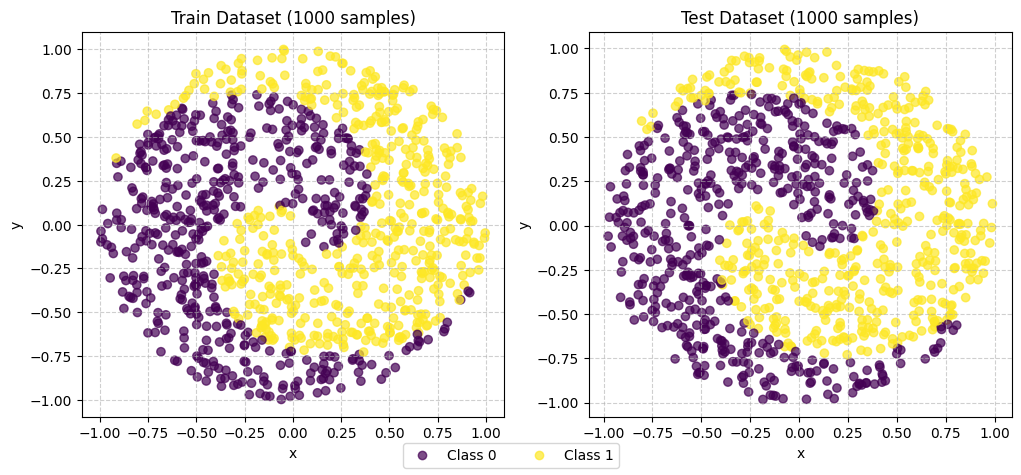

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
scatter_train = ax1.scatter(np.asarray(X_train[:, 0]), np.asarray(X_train[:, 1]), c=np.asarray(y_train), alpha=0.7)
ax1.set_title(f'Train Dataset ({len(X_train)} samples)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.grid(True, linestyle='--', alpha=0.6)

scatter_test = ax2.scatter(np.asarray(X_test[:, 0]), np.asarray(X_test[:, 1]), c=np.asarray(y_test), alpha=0.7)
ax2.set_title(f'Test Dataset ({len(X_test)} samples)')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.grid(True, linestyle='--', alpha=0.6)

handles, _ = scatter_train.legend_elements()
fig.legend(handles, ['Class 0', 'Class 1'], loc='lower center', ncol=2)
plt.show()


In [17]:
N_computation = 98
N_read_out = 2
X_train = embedding(X_train, N_computation)
X_test = embedding(X_test, N_computation)


The Hopfield model equation reads:

$$
\dot{x}_i = -\alpha x_i + \beta \sum_j A_{ij} f(x_j) + b_i,
$$

where $x_i$ is the activity of neuron $i$, $f(x)$ is the nonlinear activation function, $A$ is the adjacency matrix connecting the neurons, $\alpha$ and $\beta$ are scalar parameters, and $b$ is a bias term.

The matrix $A$ is constructed in order to ensure that the labels are fixed points of the dynamics.
However, most of its entries remain free to be optimized during training. In particular we set:

$$
A = W (I - P) + \tilde{P},
$$

where

$$
P = \sum_{\ell}
\frac{|f(x^{\ell})\rangle \langle f(x^{\ell})|}
{\langle f(x^{\ell}) | f(x^{\ell}) \rangle},
$$

with the index $\ell$ running over the attractors, and

$$
\tilde{P} =
\frac{1}{\beta}
\sum_{\ell}
\frac{|\alpha x^{\ell} - b\rangle \langle f(x^{\ell})|}
{\langle f(x^{\ell}) | f(x^{\ell}) \rangle},
$$

with the entries of the matrix $W$ trainable parameters that can be freely optimized.

By choosing $x^{\ell}$ and $f(x^{\ell})$ to be mutually orthogonal, and by substituting $P$ and $\tilde{P}$ into the Hopfield equation, we obtain

$$
\dot{x}^{\ell} = 0
\qquad \forall \, \ell.
$$
Indeed, evaluating $\dot{x}$ at a particular attractor $x^k$,
$$
-\alpha x^k + \beta \left(W(I-P) + \tilde{P} \right) f(x^k) + b=0,
$$

since
$$
(I-P)|f(x^k)\rangle = |f(x^k)\rangle - |f(x^k)\rangle = 0,
$$

and
$$
\tilde{P}|f(x^k)\rangle = \frac{\alpha x^k - b}{\beta}.
$$

In [18]:
def activation_function(x, c=jnp.float32(1.0 / 8.0)):
    """Nonlinear activation f(x) used by the Hopfield dynamics."""
    return x**2 / (c + x**2)


def activation_derivative(x, c=jnp.float32(1.0 / 8.0)):
    """Derivative of f(x) = x^2 / (c + x^2), used for Jacobian analysis."""
    return 2.0 * c * x / (c + x**2) ** 2


def init_hopfield_model(key, n_total, n_output, beta=0.1, alpha=1.0, attractor_value=1.0, bias_flag=True):
    alpha = jnp.asarray(alpha, dtype=jnp.float32)
    beta = jnp.asarray(beta, dtype=jnp.float32)
    c = jnp.asarray(1.0 / 8.0, dtype=jnp.float32)

    # Trainable weights. This matches a Kaiming/He normal initialization for a square matrix.
    w_key, _ = random.split(key)
    W = random.normal(w_key, (n_total, n_total), dtype=jnp.float32) * jnp.sqrt(
        jnp.asarray(2.0 / n_total, dtype=jnp.float32)
    )
    bias = jnp.zeros((n_total,), dtype=jnp.float32)

    # Build orthogonal attractors. For N_OUT = 2 this is equivalent to the original notebook.
    x_attractors = jnp.zeros((n_total, n_output), dtype=jnp.float32)
    attractor_rows = jnp.arange(n_output)
    x_attractors = x_attractors.at[attractor_rows, attractor_rows].set(
        jnp.asarray(attractor_value, dtype=jnp.float32)
    )
    fx_attractors = activation_function(x_attractors, c)

    norm_fx_attr = jnp.sum(fx_attractors**2, axis=0, keepdims=True)
    normalized_fx_attr = fx_attractors / norm_fx_attr

    # Projector P = sum_attractors |f(x)><f(x)| / <f(x)|f(x)>.
    P = fx_attractors @ normalized_fx_attr.T
    I_minus_P = jnp.eye(n_total, dtype=jnp.float32) - P

    params = {
        "W": W,
        "bias": bias,
    }
    constants = {
        "alpha": alpha,
        "beta": beta,
        "c": c,
        "bias_flag": jnp.asarray(bool(bias_flag)),
        "P": P,
        "I_minus_P": I_minus_P,
        "x_attractors": x_attractors,
        "fx_attractors": fx_attractors,
        "norm_fx_attr": norm_fx_attr,
        "normalized_fx_attr": normalized_fx_attr,
        "attractor_1": x_attractors[:, 0],
        "attractor_2": x_attractors[:, 1],
        "sigma_a1": fx_attractors[:, 0],
        "sigma_a2": fx_attractors[:, 1],
    }
    return params, constants


def adjacency_matrix(params, constants):
    """Construct A = W(I - P) + P_tilde dynamically from the current parameters."""
    P_tilde = (
        (constants["alpha"] * constants["x_attractors"] - params["bias"][:, None])
        @ constants["normalized_fx_attr"].T
    ) / constants["beta"]
    return params["W"] @ constants["I_minus_P"] + P_tilde


def drift(x, A, params, constants):
    """Hopfield velocity field: x_dot = -alpha*x + beta*A*f(x) + bias."""
    network_input = activation_function(x, constants["c"]) @ A.T
    return -constants["alpha"] * x + constants["beta"] * network_input + params["bias"]


@functools.partial(jax.jit, static_argnames=("num_steps",))
def forward_final(params, constants, x_input, num_steps, dt):
    """Integrate dynamics and return only the final state.

    The timestep loop is expressed with lax.scan so XLA can compile the whole recurrent
    computation efficiently instead of dispatching one Python operation per timestep.
    """
    A = adjacency_matrix(params, constants)
    dt = jnp.asarray(dt, dtype=x_input.dtype)

    def euler_step(x, _):
        x_next = x + drift(x, A, params, constants) * dt
        return x_next, None

    final_state, _ = lax.scan(euler_step, x_input, xs=None, length=num_steps)
    return final_state


@functools.partial(jax.jit, static_argnames=("num_steps",))
def forward_trajectory(params, constants, x_input, num_steps, dt):
    """Integrate dynamics and return the full trajectory with shape (batch, steps + 1, n_total)."""
    A = adjacency_matrix(params, constants)
    dt = jnp.asarray(dt, dtype=x_input.dtype)

    def euler_step(x, _):
        x_next = x + drift(x, A, params, constants) * dt
        return x_next, x_next

    final_state, states = lax.scan(euler_step, x_input, xs=None, length=num_steps)
    trajectory = jnp.swapaxes(jnp.concatenate([x_input[None, :, :], states], axis=0), 0, 1)
    return final_state, trajectory


def forward(params, constants, x_input, num_steps, dt, return_trajectory=True):
    """Small convenience wrapper mirroring the original PyTorch forward method."""
    if return_trajectory:
        return forward_trajectory(params, constants, x_input, num_steps=num_steps, dt=dt)
    return forward_final(params, constants, x_input, num_steps=num_steps, dt=dt), None


@functools.partial(jax.jit, static_argnames=("num_steps",))
def predict(params, constants, x_input, num_steps, dt):
    """Classify each sample by its final-state distance to the two attractors."""
    final_state = forward_final(params, constants, x_input, num_steps=num_steps, dt=dt)
    dist_to_a1 = jnp.sum((final_state - constants["attractor_1"]) ** 2, axis=1)
    dist_to_a2 = jnp.sum((final_state - constants["attractor_2"]) ** 2, axis=1)
    return jnp.where(dist_to_a1 < dist_to_a2, 0, 1).astype(jnp.int32)

def make_optimizer(learning_rate: float):
    optimizer = optax.adam(learning_rate)

    def init(params):
        return optimizer.init(params)

    def update(params, grads, opt_state):
        updates, opt_state = optimizer.update(grads, opt_state, params)
        return optax.apply_updates(params, updates), opt_state

    return init, update

def masked_mse_loss(params, constants, batch_x, batch_y, mask, num_steps, dt):
    final_state = forward_final(params, constants, batch_x, num_steps=num_steps, dt=dt)
    targets = constants["x_attractors"].T[batch_y]
    per_sample_loss = jnp.mean((final_state - targets) ** 2, axis=1)
    mask = mask.astype(per_sample_loss.dtype)
    return jnp.sum(per_sample_loss * mask) / jnp.maximum(jnp.sum(mask), 1.0)


@functools.partial(jax.jit, static_argnames=("num_steps",))
def train_step(params, opt_state, constants, batch_x, batch_y, mask, num_steps, dt):
    loss, grads = jax.value_and_grad(masked_mse_loss)(
        params, constants, batch_x, batch_y, mask, num_steps, dt
    )
    params, opt_state = optimizer_update(params, grads, opt_state)
    return params, opt_state, loss


In [27]:
## Training
N_IN = 2
N_HIDDEN = N_computation - N_read_out
N_OUT = N_read_out
DT = 0.03
STEPS = 200
EPOCHS = 100
BATCH_SIZE = 256
LEARNING_RATE = 0.01

total_neurons = N_HIDDEN + N_IN + N_OUT
key = random.PRNGKey(42)
params, constants = init_hopfield_model(key, n_total=total_neurons, n_output=N_OUT)

optimizer_init, optimizer_update = make_optimizer(LEARNING_RATE)
opt_state = optimizer_init(params)


In [28]:
print("Starting training...\n")
loss_history = []
num_train = X_train.shape[0]
start_time = time.perf_counter()

for epoch in range(EPOCHS):
    epoch_key = random.fold_in(key, epoch)
    permutation = random.permutation(epoch_key, num_train)
    epoch_loss = 0.0
    samples_seen = 0

    for i in range(0, num_train, BATCH_SIZE):
        indices = permutation[i:i + BATCH_SIZE]
        actual_batch_size = int(indices.shape[0])

        # Keep every JIT call at the same batch shape. The final partial batch is padded
        # and excluded from the loss by the mask, avoiding recompilation for a new shape.
        if actual_batch_size < BATCH_SIZE:
            padding = jnp.repeat(indices[:1], BATCH_SIZE - actual_batch_size)
            indices = jnp.concatenate([indices, padding], axis=0)

        mask = (jnp.arange(BATCH_SIZE) < actual_batch_size).astype(jnp.float32)
        batch_x, batch_y = X_train[indices], y_train[indices]

        params, opt_state, loss = train_step(
            params,
            opt_state,
            constants,
            batch_x,
            batch_y,
            mask,
            num_steps=STEPS,
            dt=DT,
        )

        epoch_loss += float(loss) * actual_batch_size
        samples_seen += actual_batch_size

    avg_loss = epoch_loss / samples_seen
    loss_history.append(avg_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        predictions = predict(params, constants, X_test, num_steps=STEPS, dt=DT)
        predictions.block_until_ready()
        accuracy = float(jnp.mean((predictions == y_test).astype(jnp.float32)) * 100.0)
        print(f"Epoch [{epoch+1:3d}/{EPOCHS}] | MSE Loss: {avg_loss:.6f} | Test Accuracy: {accuracy:.2f}%")

elapsed = time.perf_counter() - start_time
print(f"\nTraining Complete! Elapsed time: {elapsed:.2f} s")


Starting training...

Epoch [  1/100] | MSE Loss: 0.009649 | Test Accuracy: 50.00%
Epoch [ 10/100] | MSE Loss: 0.003780 | Test Accuracy: 73.30%
Epoch [ 20/100] | MSE Loss: 0.003496 | Test Accuracy: 74.40%
Epoch [ 30/100] | MSE Loss: 0.003506 | Test Accuracy: 73.70%
Epoch [ 40/100] | MSE Loss: 0.003384 | Test Accuracy: 73.50%
Epoch [ 50/100] | MSE Loss: 0.003227 | Test Accuracy: 76.50%
Epoch [ 60/100] | MSE Loss: 0.003214 | Test Accuracy: 76.80%
Epoch [ 70/100] | MSE Loss: 0.002987 | Test Accuracy: 76.90%
Epoch [ 80/100] | MSE Loss: 0.002885 | Test Accuracy: 78.60%
Epoch [ 90/100] | MSE Loss: 0.002745 | Test Accuracy: 79.00%
Epoch [100/100] | MSE Loss: 0.002500 | Test Accuracy: 82.00%

Training Complete! Elapsed time: 6.79 s


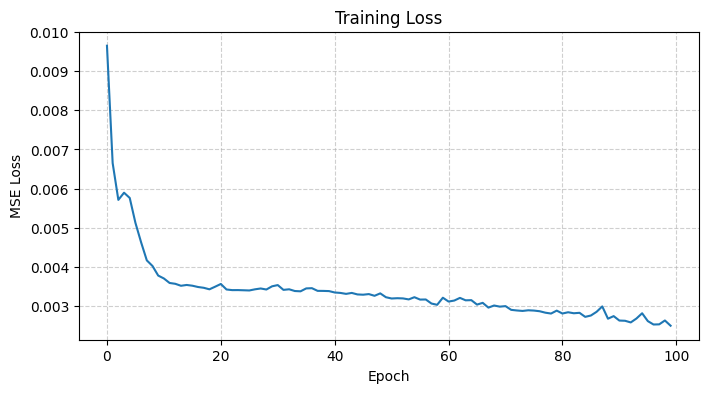

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [22]:
print("\nEvaluating on Test Dataset...")

predictions = predict(params, constants, X_test, num_steps=STEPS, dt=DT)
correct = int(jnp.sum(predictions == y_test))
total = y_test.shape[0]
accuracy = (correct / total) * 100.0

print(f"Test Accuracy: {accuracy:.2f}% ({correct}/{total} correct)")

final_state, _ = forward(params, constants, X_test, num_steps=STEPS, dt=DT, return_trajectory=False)
dist_to_a1 = jnp.sum((final_state - constants["attractor_1"]) ** 2, axis=1)
dist_to_a2 = jnp.sum((final_state - constants["attractor_2"]) ** 2, axis=1)



Evaluating on Test Dataset...
Test Accuracy: 82.00% (820/1000 correct)


In [23]:

def jacobian_eigvals(params, constants, attractor_index=0, plot_flag=False, dt=None, return_jacobian=False):
    """Compute and optionally plot Jacobian eigenvalues at a given attractor."""
    A = adjacency_matrix(params, constants)
    x_star = constants["x_attractors"][:, attractor_index]
    I = jnp.eye(x_star.shape[0], dtype=x_star.dtype)
    D_fx = jnp.diag(activation_derivative(x_star, constants["c"]))

    # Jacobian of x_dot = -alpha*x + beta*A*f(x) + bias.
    J = -constants["alpha"] * I + constants["beta"] * A @ D_fx
    eigvals = jnp.linalg.eigvals(J)

    if plot_flag:
        eig_np = np.asarray(eigvals)

        plt.figure(figsize=(6, 5))
        plt.scatter(eig_np.real, eig_np.imag, alpha=0.8)
        plt.axvline(0.0, linestyle='--', linewidth=1)
        plt.axhline(0.0, linestyle='--', linewidth=1)
        plt.xlabel('Real part')
        plt.ylabel('Imaginary part')
        plt.title(f'Jacobian eigenvalues at attractor {attractor_index}')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()

        print("Max real eigenvalue:", float(jnp.max(jnp.real(eigvals))))

        if dt is not None:
            print("Max abs Euler eigenvalue:", float(jnp.max(jnp.abs(1.0 + dt * eigvals))))

    if return_jacobian:
        return eigvals, J

    return eigvals

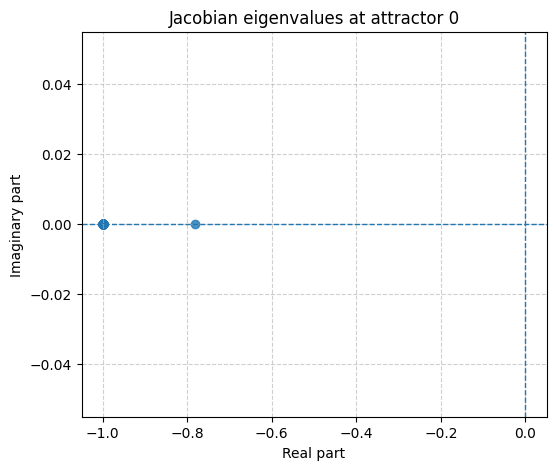

Max real eigenvalue: -0.7825400233268738
Max abs Euler eigenvalue: 0.9765238165855408


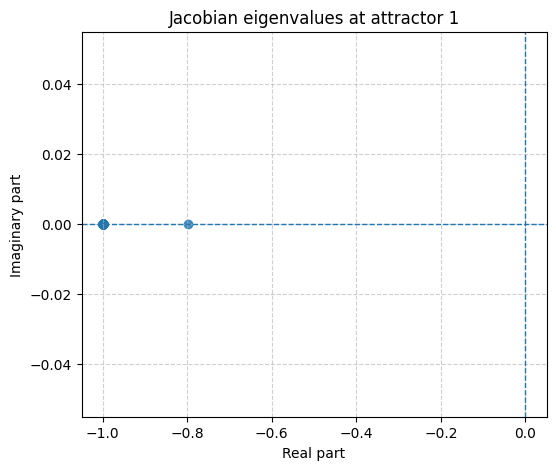

Max real eigenvalue: -0.7988982796669006
Max abs Euler eigenvalue: 0.9760330319404602


In [24]:
eigvals_1 = jacobian_eigvals(params, constants, attractor_index=0, plot_flag=True, dt=DT)
eigvals_2 = jacobian_eigvals(params, constants, attractor_index=1, plot_flag=True, dt=DT)
